In [2]:
import numpy as np

def Rz(theta):
    """
    Matriz de rotação em torno do eixo z por um ângulo theta (em radianos).
    """
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])

def Ry(phi):
    """
    Matriz de rotação em torno do eixo y por um ângulo phi (em radianos).
    """
    return np.array([
        [ np.cos(phi), 0, np.sin(phi)],
        [ 0,           1, 0         ],
        [-np.sin(phi), 0, np.cos(phi)]
    ])

/home/gpereira/miniconda3/envs/py3_10/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['rotations']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(


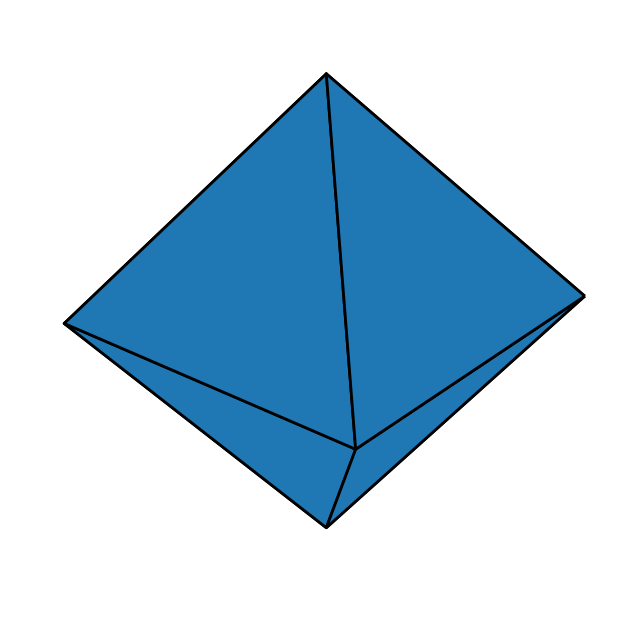

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from wulffpack import SingleCrystal
N = 11
colors = plt.cm.tab20(np.linspace(0, 1, N))

# Define surface energies for a cubic crystal (e.g., FCC or BCC)
surface_energies = {
    (0, 0, 1): 0.3,
    (0, 1, 1): 0.22,
    (1, 1, 1): 0.16
}

COLORS = {
    (0, 0, 1): colors[2],
    (0, 1, 1): colors[3],
    (1, 1, 1): colors[0]
}

theta = np.pi/5
phi = 0

# Create a Wulff shape
crystal = SingleCrystal(surface_energies)

rotate_matrix = Rz(theta) @ Ry(phi)
crystal.rotate_particle(rotate_matrix)

# Plot the Wulff shape
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
crystal.make_plot(ax=ax, alpha=1, linewidth=2, colors = COLORS)

# Display the plot
plt.savefig('7.png', transparent=True, dpi=600)
plt.show()


In [4]:
def poly_energy(crystal_, surface_energies_):
    E_poly = 0
    for facet in surface_energies_.keys():
        E_poly += crystal_.facet_fractions.get(facet, 0.) * surface_energies_[facet]
    return E_poly

In [5]:
poly_energy(crystal, surface_energies)

np.float64(0.16)

In [6]:
surface_energies

{(0, 0, 1): 0.3, (0, 1, 1): 0.22, (1, 1, 1): 0.16}

{(0, 0, 1): 0.09, (0, 1, 1): 0.1, (1, 1, 1): 0.16}
{(0, 0, 1): 0.09, (0, 1, 1): 0.16, (1, 1, 1): 0.16}
{(0, 0, 1): 0.15, (0, 1, 1): 0.1, (1, 1, 1): 0.16}
{(0, 0, 1): 0.16, (0, 1, 1): 0.16, (1, 1, 1): 0.16}
{(0, 0, 1): 0.15, (0, 1, 1): 0.22, (1, 1, 1): 0.16}
{(0, 0, 1): 0.23, (0, 1, 1): 0.16, (1, 1, 1): 0.16}
{(0, 0, 1): 0.3, (0, 1, 1): 0.22, (1, 1, 1): 0.16}

In [7]:
X = [0, 1, 1, 2, 3, 3, 4]
Y = [0.095, 0.09, 0.1, 0.1562, 0.155, 0.16, 0.16]

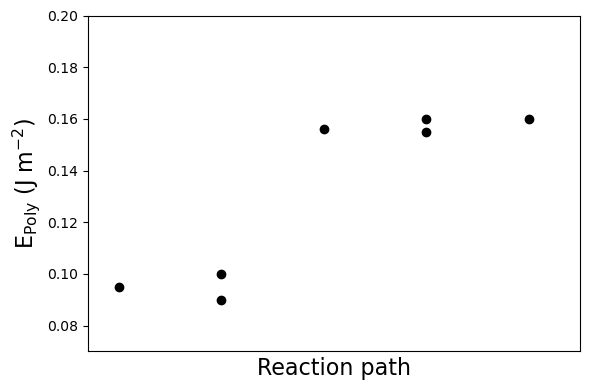

In [8]:
fig = plt.figure(figsize=(6, 4))

plt.scatter(X, Y, color="black")
plt.xlabel("Reaction path", fontsize=16)
plt.ylabel(r"E$_{\mathrm{Poly}}$ (J m$^{-2}$)", fontsize=16)
plt.ylim(0.07, 0.2)
plt.xlim(-0.3, 4.5)
plt.xticks([])
plt.grid(False)
plt.tight_layout()
plt.savefig('E_poly.png', dpi=600)
plt.show()